# Energy Consumption Time Series Forecasting

## DevelopersHub Corporation — Advanced Data Science Internship

### Objective
The objective of this project is to forecast household energy consumption using historical time-series data.

### Techniques Used
- Time Series Preprocessing
- Feature Engineering
- ARIMA Forecasting
- Prophet Forecasting
- XGBoost Regression
- Model Comparison

### Dataset
Household Power Consumption Dataset

# 1. Importing Required Libraries

In this step, we import libraries required for:
- Data analysis
- Time-series processing
- Forecasting
- Visualization

In [2]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 888.3 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/12.1 MB 825.6 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/12.1 MB 825.6 kB/s eta 0:00:14
   --- ------------------------------------ 1.0/12.1 MB 830.9 kB/s eta 0:00:14
   ---- ----------------------------------- 1.3/12.1 MB 841.0 kB/s eta 0:00:13
   ----- ---------------------------------- 1.6/12.1 MB 885.9 kB/s eta 0:00:12
   ----- ---------------------------------- 1.6/12.1 MB 885.9 kB/s eta 0:00:12
   ------ --------------------------------- 1.8/12.1 MB 857.2 kB/s eta 0:00:12
   ------ --------

In [4]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 849.0 kB/s eta 0:02:00
   ---------------------------------------- 0.5/101.7 MB 849.0 kB/s eta 0:02:00
   ---------------------------------------- 0.8/101.7 MB 868.1 kB/s eta 0:01:57
   ---------------------------------------- 1.0/101.7 MB 896.7 kB/s eta 0:01:53
    --------------------------------------- 1.3/101.7 MB 998.2 kB/s eta 0:01:41
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:29
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:29
    --------------

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

# 2. Loading the Dataset

The dataset contains household electricity consumption measurements recorded over time.

In [6]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False
)

# 3. Previewing the Dataset

We inspect the first few rows to understand:
- Dataset structure
- Column names
- Feature values

In [7]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


# 4. Dataset Information

This step helps us understand:
- Data types
- Missing values
- Dataset dimensions

## 4.1 Dataset Shape

In [8]:
df.shape

(2075259, 9)

## 4.2 Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


# 5. Data Preprocessing

Time-series forecasting requires:
- Proper datetime formatting
- Numerical conversion
- Missing value handling

## 5.1 Creating Datetime Column

We combine:
- Date
- Time

into a single datetime feature.

In [10]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

## 5.2 Setting Datetime as Index

The datetime column is used as the dataset index for time-series operations.

In [11]:
df.set_index('Datetime', inplace=True)

## 5.3 Converting Columns to Numeric Format

Some numerical columns are currently stored as text.

We convert them into proper numerical format for analysis and forecasting.

In [12]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

## 5.4 Handling Missing Values

Missing values are removed to ensure clean time-series forecasting.

In [13]:
df = df.dropna()

# 6. Time-Series Resampling

The dataset contains high-frequency readings.

We resample the data into hourly averages for easier forecasting and visualization.

In [15]:
hourly_data = df['Global_active_power'].resample('H').mean()

# 7. Energy Consumption Visualization

We visualize household energy usage over time to identify:
- Trends
- Seasonal patterns
- Consumption fluctuations

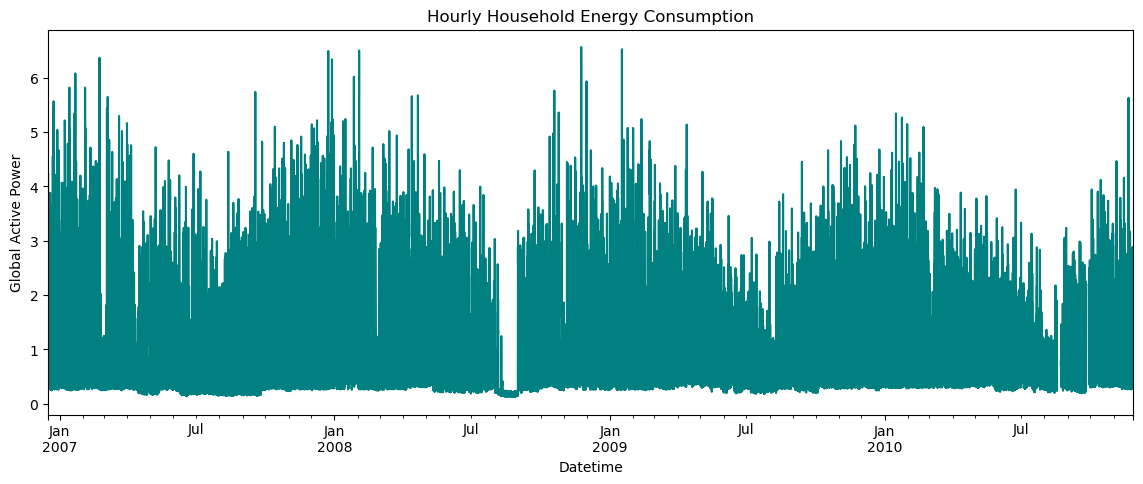

In [16]:
plt.figure(figsize=(14,5))

hourly_data.plot(color='teal')

plt.title("Hourly Household Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power")

plt.show()

# 8. Feature Engineering

Time-based features help machine learning models identify temporal patterns.

## 8.1 Engineering Time Features

We create:
- Hour
- Day
- Month
- Weekday

In [27]:
hourly_data = hourly_data.dropna()

In [28]:
ts_df = hourly_data.to_frame()

ts_df['Hour'] = ts_df.index.hour
ts_df['Day'] = ts_df.index.day
ts_df['Month'] = ts_df.index.month
ts_df['Weekday'] = ts_df.index.weekday

## 8.2 Previewing Engineered Features

We inspect the newly created time-based features.

In [29]:
ts_df.head()

,Global_active_power,Hour,Day,Month,Weekday
Datetime,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5
2006-12-16 18:00:00,3.632200,18,16,12,5
2006-12-16 19:00:00,3.400233,19,16,12,5
2006-12-16 20:00:00,3.268567,20,16,12,5
2006-12-16 21:00:00,3.056467,21,16,12,5


# 9. Train-Test Split

We divide the time-series data into:
- Training data
- Testing data

This allows forecasting evaluation on unseen future values.

## 9.1 Feature and Target Separation

In [30]:
X = ts_df[['Hour', 'Day', 'Month', 'Weekday']]

y = ts_df['Global_active_power']

## 9.2 Chronological Train-Test Split

For time-series forecasting:
- Data must be split chronologically
- Future data should never appear in training

In [31]:
split_index = int(len(ts_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# 10. XGBoost Forecasting Model

XGBoost is a powerful gradient boosting algorithm commonly used for regression and forecasting tasks.

## 10.1 Creating XGBoost Regressor

In [32]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

## 10.2 Training the XGBoost Model

The model is trained using historical energy consumption data.

In [33]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# 11. Forecast Generation

After training the model, we generate predictions on the test dataset.

In [34]:
xgb_pred = xgb_model.predict(X_test)

# 12. Forecast Evaluation

We evaluate forecasting performance using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

## 12.1 Mean Absolute Error

In [35]:
mae = mean_absolute_error(y_test, xgb_pred)

print("MAE:", mae)

MAE: 0.4440785008125989


## 12.2 Root Mean Squared Error (RMSE)

In [36]:
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("RMSE:", rmse)

RMSE: 0.6064527532466956


# 13. Actual vs Predicted Visualization

We compare:
- Actual energy consumption
- Predicted energy consumption

to visually evaluate forecasting performance.

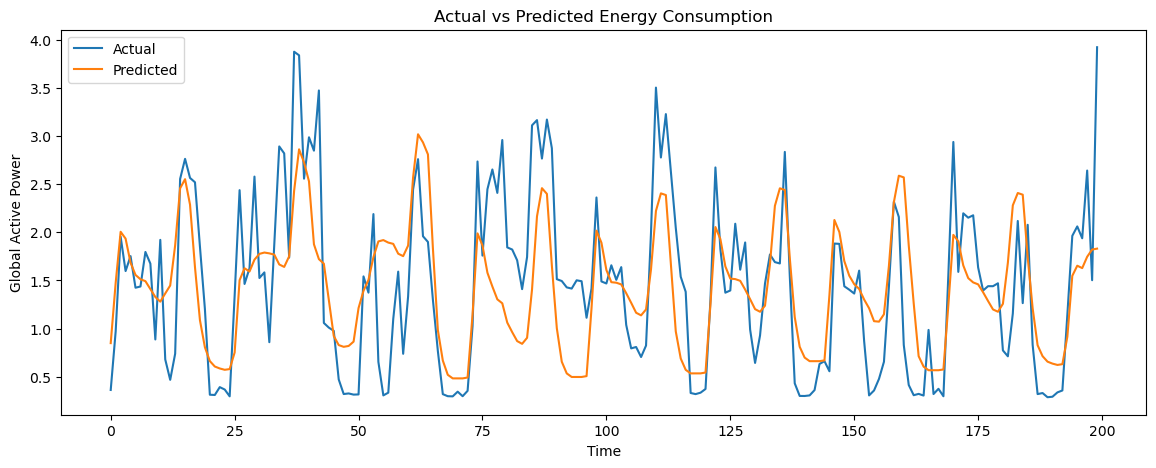

In [37]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgb_pred[:200],
    label='Predicted'
)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.legend()

plt.show()

# 14. ARIMA Forecasting Model

ARIMA is a classical statistical method used for time-series forecasting.

## 14.1 ARIMA Model Training

We train ARIMA using:
- p = 2
- d = 1
- q = 2

In [38]:
arima_model = ARIMA(
    y_train,
    order=(2,1,2)
)

## 14.2 Fitting the ARIMA Model

In [40]:
arima_result = arima_model.fit()

## 14.3 Generating ARIMA Forecasts

In [41]:
arima_pred = arima_result.forecast(steps=len(y_test))

# 15. ARIMA Model Evaluation

We evaluate ARIMA forecasting performance using:
- MAE
- RMSE

## 15.1 Mean Absolute Error

In [42]:
arima_mae = mean_absolute_error(y_test, arima_pred)

print("ARIMA MAE:", arima_mae)

ARIMA MAE: 0.8113783029770656


## 15.2 Root Mean Squared Error (RMSE)

In [43]:
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))

print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 0.9349425851217777


# 16. Model Comparison

We compare forecasting performance between:
- XGBoost
- ARIMA

In [44]:
comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'ARIMA'],
    'MAE': [mae, arima_mae],
    'RMSE': [rmse, arima_rmse]
})

In [45]:
comparison_df

,Model,MAE,RMSE
0,XGBoost,0.444079,0.606453
1,ARIMA,0.811378,0.934943


## 16.1 Model Performance Visualization

This chart compares forecasting errors between:
- XGBoost
- ARIMA

<Figure size 800x500 with 0 Axes>

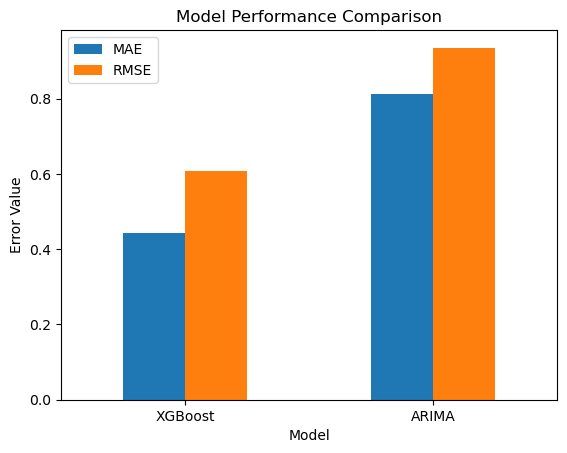

In [46]:
plt.figure(figsize=(8,5))

comparison_df.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar'
)

plt.title("Model Performance Comparison")
plt.ylabel("Error Value")

plt.xticks(rotation=0)

plt.show()

# 17. Conclusion

## Project Summary

This project focused on forecasting household energy consumption using time-series modeling techniques.

The workflow included:
- Time-series preprocessing
- Datetime handling
- Feature engineering
- XGBoost forecasting
- ARIMA forecasting
- Model comparison
- Forecast visualization

---

## Key Findings

- XGBoost successfully captured temporal energy consumption patterns using engineered time features.
- ARIMA provided a strong statistical baseline for forecasting.
- Forecasting accuracy was evaluated using:
  - MAE
  - RMSE
- Model comparison showed differences in predictive performance between machine learning and statistical approaches.

---

## Business Impact

Energy forecasting can help:
- Optimize electricity usage
- Improve smart-grid planning
- Reduce operational costs
- Support energy demand management

---

## Final Outcome

The project successfully demonstrated:
- Time-series forecasting
- Feature engineering
- Regression modeling
- Statistical forecasting
- Comparative model evaluation